# **04 LangGraph 기본 사용법 - 노드와 엣지 연결**

### 학습 내용
1. 노드(Node)와 엣지(Edge) 개념 이해
2. 순차적 노드 연결
5. 조건부 엣지(Conditional Edge) 활용

## 1. 환경 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. 노드 순차 연결

In [7]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# State 정의
class State(TypedDict):
    text: str
    step: int

In [8]:
# 여러 노드 정의
def step1(state: State):
    print("Step 1: 입력 처리")
    return {"text": state["text"] + " -> Step1", "step": 1}

def step2(state: State):
    print("Step 2: 데이터 변환")
    return {"text": state["text"] + " -> Step2", "step": 2}

def step3(state: State):
    print("Step 3: 결과 생성")
    return {"text": state["text"] + " -> Step3", "step": 3}

In [9]:
# 그래프 구성 - 순차 연결
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("step1", step1)
graph_builder.add_node("step2", step2)
graph_builder.add_node("step3", step3)

# 엣지 연결: START -> step1 -> step2 -> step3 -> END
graph_builder.add_edge(START, "step1")
graph_builder.add_edge("step1", "step2")
graph_builder.add_edge("step2", "step3")
graph_builder.add_edge("step3", END)

graph = graph_builder.compile()

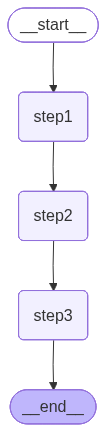

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error: {e}")

In [11]:
# 그래프 실행
result = graph.invoke({"text": "START", "step": 0})

print("\n실행 결과:")
print(f"최종 텍스트: {result['text']}")
print(f"최종 단계: {result['step']}")

Step 1: 입력 처리
Step 2: 데이터 변환
Step 3: 결과 생성

실행 결과:
최종 텍스트: START -> Step1 -> Step2 -> Step3
최종 단계: 3


🔥 TODO: **"text" 를 리듀서 함수를 통해 자동 누적되게 변경한다면?**

### 예제 1: 다단계 번역 시스템

영어 → 한국어 → 일본어로 순차 번역하는 시스템

**요구사항**:
1. State에 `original_text`, `korean_text`, `japanese_text` 필드 정의
2. `translate_to_korean` 노드: 영어를 한국어로 번역
3. `translate_to_japanese` 노드: 한국어를 일본어로 번역
4. START → translate_to_korean → translate_to_japanese → END
5. 각 단계의 결과 출력

**예상 출력**:
```
원문(영어): Hello, how are you?
한국어: 안녕하세요, 어떻게 지내세요?
일본어: こんにちは、お元気ですか？
```

In [17]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage

# LLM 초기화
llm = init_chat_model("gpt-4o-mini")

class InputState(TypedDict):
    original_text: str

class OutputState(TypedDict):
    original_text: str
    korean_text: str
    japanese_text: str

class OverallState(InputState, OutputState):
    pass

In [18]:
# 영어 → 한국어 번역 노드
def translate_to_korean(state: State):
    print("영어 → 한국어 번역 중...")
    
    messages = [
        SystemMessage(content="You are a professional translator. Translate the given English text to Korean. Return only the translation."),
        HumanMessage(content=state["original_text"])
    ]
    
    response = llm.invoke(messages)
    korean_text = response.content
    
    print(f"한국어 번역: {korean_text}")
    return {"korean_text": korean_text}

# 한국어 → 일본어 번역 노드
def translate_to_japanese(state: State):
    print("한국어 → 일본어 번역 중...")
    
    messages = [
        SystemMessage(content="You are a professional translator. Translate the given Korean text to Japanese. Return only the translation."),
        HumanMessage(content=state["korean_text"])
    ]
    
    response = llm.invoke(messages)
    japanese_text = response.content
    
    print(f"일본어 번역: {japanese_text}")
    return {"japanese_text": japanese_text}

In [20]:
# 그래프 구성
graph_builder = StateGraph(State, input_schema=InputState, output_schema=OutputState)

# 노드 추가
graph_builder.add_node("translate_to_korean", translate_to_korean)
graph_builder.add_node("translate_to_japanese", translate_to_japanese)

# 엣지 연결
graph_builder.add_edge(START, "translate_to_korean")
graph_builder.add_edge("translate_to_korean", "translate_to_japanese")
graph_builder.add_edge("translate_to_japanese", END)

# 그래프 컴파일
graph = graph_builder.compile()

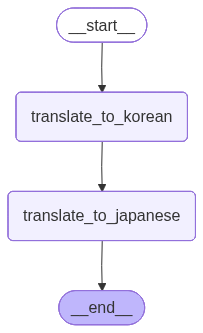

In [21]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [24]:
# 실행
input_text = "Hello, how are you?"
result = graph.invoke({
    "original_text": input_text
})

# 결과 출력
print("\n" + "="*50)
print("번역 결과:")
print(f"원문(영어): {result['original_text']}")
print(f"한국어: {result['korean_text']}")
print(f"일본어: {result['japanese_text']}")

영어 → 한국어 번역 중...
한국어 번역: 안녕하세요, 어떻게 지내세요?
한국어 → 일본어 번역 중...
일본어 번역: こんにちは、お元気ですか？

번역 결과:
원문(영어): Hello, how are you?
한국어: 안녕하세요, 어떻게 지내세요?
일본어: こんにちは、お元気ですか？


### 📖 과제 1: 다단계 LLM 시스템

여러 단계로 구성된 시스템을 구현해보세요.

In [ ]:
# CODE HERE

## 3. 조건부 엣지 (Conditional Edge)

조건에 따라 다른 노드로 이동하는 조건부 엣지를 구현합니다.

https://reference.langchain.com/python/langgraph/graph/state/StateGraph/add_conditional_edges

In [25]:
from typing import Literal

# State 정의
class State(TypedDict):
    number: int
    result: str

# 노드 정의
def check_number(state: State):
    print(f"숫자 확인: {state['number']}")
    return state

def process_positive(state: State):
    print("양수 처리")
    return {"result": f"{state['number']}는 양수입니다."}

def process_negative(state: State):
    print("음수 처리")
    return {"result": f"{state['number']}는 음수입니다."}

def process_zero(state: State):
    print("0 처리")
    return {"result": "숫자는 0입니다."}

In [26]:
# 조건 함수 정의
def decide_path(state: State) -> Literal["positive", "negative", "zero"]:
    """숫자에 따라 다음 노드를 결정"""
    if state["number"] > 0:
        return "양수"
    elif state["number"] < 0:
        return "음수"
    else:
        return "영"

In [27]:
# 그래프 구성
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("check", check_number)
graph_builder.add_node("positive", process_positive)
graph_builder.add_node("negative", process_negative)
graph_builder.add_node("zero", process_zero)

# 시작 엣지
graph_builder.add_edge(START, "check")

# 조건부 엣지 추가
graph_builder.add_conditional_edges(
    "check",  # 출발 노드
    decide_path,  # 조건 함수
    {
        "양수": "positive", # 조건 함수의 return 값 : 다음 노드의 이름
        "음수": "negative",
        "영": "zero",
    }
)

# 모든 경로가 END로
graph_builder.add_edge("positive", END)
graph_builder.add_edge("negative", END)
graph_builder.add_edge("zero", END)

graph = graph_builder.compile()

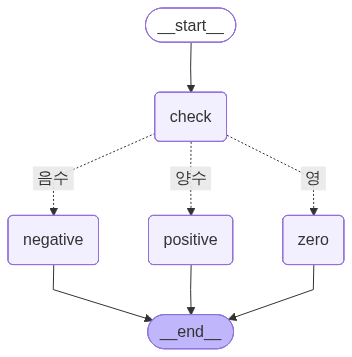

In [28]:
# 시각화
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [29]:
# 여러 숫자로 테스트
test_numbers = [5, -3, 0, 10, -7]

for num in test_numbers:
    print(f"\n{'='*50}")
    result = graph.invoke({"number": num, "result": ""})
    print(f"결과: {result['result']}")


숫자 확인: 5
양수 처리
결과: 5는 양수입니다.

숫자 확인: -3
음수 처리
결과: -3는 음수입니다.

숫자 확인: 0
0 처리
결과: 숫자는 0입니다.

숫자 확인: 10
양수 처리
결과: 10는 양수입니다.

숫자 확인: -7
음수 처리
결과: -7는 음수입니다.


### 📖 과제 2: 감정 기반 응답 시스템

텍스트의 감정을 분석하고, 감정에 따라 다른 응답을 생성하는 시스템을 만드세요.

**요구사항**:
1. State에 `user_text`, `sentiment`, `response` 필드 정의
2. `analyze_sentiment` 노드: 감정 분석 (positive/negative/neutral 반환)
3. `route_by_sentiment` 함수: 감정에 따라 경로 결정
4. 감정별 응답 노드 3개: `respond_positive`, `respond_negative`, `respond_neutral`
5. 조건부 엣지로 연결
6. 다양한 텍스트로 테스트

**힌트**: 
- LLM에게 "Analyze sentiment and return only: positive, negative, or neutral"
- `add_conditional_edges` 사용
- 각 응답 노드는 감정에 맞는 톤으로 답변

**예상 출력**:
```
입력: "I love this product!"
감정: positive
응답: "That's wonderful to hear! ..."
```

In [ ]:
# CODE HERE

<details>

<summary>모범 답안 펼쳐보기</summary>

```python
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage

# LLM 초기화
llm = init_chat_model("gpt-4o-mini")

# State 정의
class State(TypedDict):
    user_text: str
    sentiment: str
    response: str

# 감정 분석 노드
def analyze_sentiment(state: State):
    print(f"감정 분석 중: '{state['user_text']}'")

    messages = [
        SystemMessage(content="주어진 텍스트의 감정을 분석하고, 긍정적이면 'positive', 부정적이면 'negative', 중립적이면 'neutral'이라는 단어 하나만 반환하세요."),
        HumanMessage(content=state["user_text"])
    ]

    result = llm.invoke(messages)
    sentiment = result.content.strip().lower()

    print(f"감정 분석 결과: {sentiment}")
    return {"sentiment": sentiment}

# 감정에 따라 경로 결정
def route_by_sentiment(state: State) -> Literal["positive", "negative", "neutral"]:
    """감정에 따라 다음 노드를 결정"""
    sentiment = state["sentiment"]

    if "positive" in sentiment:
        return "positive"
    elif "negative" in sentiment:
        return "negative"
    else:
        return "neutral"

# 긍정적 응답 노드
def respond_positive(state: State):
    print("긍정적 응답 생성 중...")

    messages = [
        SystemMessage(content="당신은 열정적이고 쾌활한 어시스턴트입니다. 사용자의 긍정적인 메시지에 동일한 열정으로 응답하세요."),
        HumanMessage(content=state["user_text"])
    ]

    result = llm.invoke(messages)
    response = result.content

    return {"response": response}

# 부정적 응답 노드
def respond_negative(state: State):
    print("부정적 응답 생성 중...")

    messages = [
        SystemMessage(content="당신은 공감적이고 지원적인 어시스턴트입니다. 사용자의 부정적인 메시지에 대해 주의 깊고 이해심 있게 응답하세요."),
        HumanMessage(content=state["user_text"])
    ]

    result = llm.invoke(messages)
    response = result.content

    return {"response": response}

# 중립적 응답 노드
def respond_neutral(state: State):
    print("중립적 응답 생성 중...")

    messages = [
        SystemMessage(content="당신은 전문적이고 정보 제공에 능숙한 어시스턴트입니다. 사용자의 중립적인 메시지에 대해 유용한 정보를 제공하세요."),
        HumanMessage(content=state["user_text"])
    ]

    result = llm.invoke(messages)
    response = result.content

    return {"response": response}

# 그래프 구성
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("analyze_sentiment", analyze_sentiment)
graph_builder.add_node("positive", respond_positive)
graph_builder.add_node("negative", respond_negative)
graph_builder.add_node("neutral", respond_neutral)

# 엣지 연결
graph_builder.add_edge(START, "analyze_sentiment")

# 조건부 엣지
graph_builder.add_conditional_edges(
    "analyze_sentiment",
    route_by_sentiment,
    {
        "positive": "positive",
        "negative": "negative",
        "neutral": "neutral",
    }
)

# 모든 응답 노드를 END로 연결
graph_builder.add_edge("positive", END)
graph_builder.add_edge("negative", END)
graph_builder.add_edge("neutral", END)

# 그래프 컴파일
graph = graph_builder.compile()

# 시각화
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

# 다양한 텍스트로 테스트
test_texts = [
    "이 제품 정말 좋아요! 놀라워요!",
    "이거 최악이에요. 정말 실망했어요.",
    "오늘 날씨는 흐리네요.",
    "와! 이거 최고예요!",
    "이 서비스에 너무 화가 나요."
]

for text in test_texts:
    print("\n" + "="*70)
    result = graph.invoke({
        "user_text": text,
        "sentiment": "",
        "response": ""
    })

    print(f"입력: {result['user_text']}")
    print(f"감정: {result['sentiment']}")
    print(f"응답: {result['response']}")
```


</details>

---
### 참고 자료

- [LangGraph 노드와 엣지](https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes)
- [LangGraph 조건부 엣지](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges)
- [LangGraph 병렬 실행](https://langchain-ai.github.io/langgraph/how-tos/branching/)